In [1]:
import os
import sys
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import loadtxt
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier 
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import SGDClassifier, LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np
import os
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.feature_selection import *
from optuna.integration import OptunaSearchCV
import optuna
import imblearn
import cupy
from cuml import RandomForestClassifier as cuRF
import cudf
import random
import time
import umap
%load_ext memory_profiler

/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/cudf/utils/gpu_utils.py:162: UserWarning: No NVIDIA GPU detected
  warnings.warn("No NVIDIA GPU detected")


In [2]:
from sklearn.decomposition import TruncatedSVD, PCA

In [ ]:
dataset_druggable = pd.read_csv("../input/combined_DepMap_21Q3_druggable.csv")
dataset_ccle = pd.read_csv("../input/combined_DepMap_21Q3_CCLE_expression.csv")
druggable_X = dataset_druggable.iloc[:, 1:-4686]
druggable_y = dataset_druggable.iloc[:, -4686:]
ccle_X = dataset_ccle.iloc[:, 1:-4686]
ccle = dataset_ccle.iloc[:, -4686:]


In [ ]:
# Calculate mean and std for each column
stats_df = pd.DataFrame({
    'feature': drug_X.columns,
    'mean': drug_X.mean(),
    'std': drug_X.std()
})

# Sort by standard deviation in descending order
stats_df = stats_df.sort_values('std', ascending=False)

x

In [3]:
dataset = pd.read_csv("../input/combined_DepMap_21Q3.csv")
num_gene = 17651
drug_X = dataset.iloc[:, 1:num_gene+1]
drug_y = dataset.iloc[:, -4686:]
drug_list = drug_y.columns.tolist()

In [4]:
# simulate a dataset like drug_X via drug_y labels
def simulate_data_gaussian(y, n_features=5, class_separation=2.0, noise_level=0.5):
    """
    Generate features X based on binary labels y using different Gaussian distributions
    
    Parameters:
    - y: binary vector (1s and 0s)
    - n_features: number of features to generate
    - class_separation: how separated the classes should be
    - noise_level: amount of noise to add
    """
    n_samples = len(y)
    X = np.zeros((n_samples, n_features))
    
    # Define different means for each class
    mean_class_0 = np.random.randn(n_features) - class_separation/2
    mean_class_1 = np.random.randn(n_features) + class_separation/2
    
    for i in tqdm(range(n_samples)):
        if y[i] == 0:
            X[i] = np.random.multivariate_normal(
                mean_class_0, 
                np.eye(n_features) * noise_level
            )
        else:
            X[i] = np.random.multivariate_normal(
                mean_class_1, 
                np.eye(n_features) * noise_level
            )
    
    return X

In [5]:
from tqdm import tqdm

In [6]:
sim_X = simulate_data_gaussian(drug_y['BRD-K42805893-001-04-9::2.5::HTS'], n_features = 170)

100%|██████████| 924/924 [00:03<00:00, 287.41it/s]


In [7]:
# Create UMAP embedding
reducer = umap.UMAP(n_components=5, random_state=42)
embedding = reducer.fit_transform(sim_X)
pca = PCA(5)
pca_emb = pca.fit_transform(sim_X)

/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [8]:
cell_meta = pd.read_csv('../input/cell_meta.csv', header = None)
cell_meta_dict = cell_meta.set_index(0)[1].to_dict()
cell_meta_dict['CCLFPEDS0001T'] = 'KIDNEY'

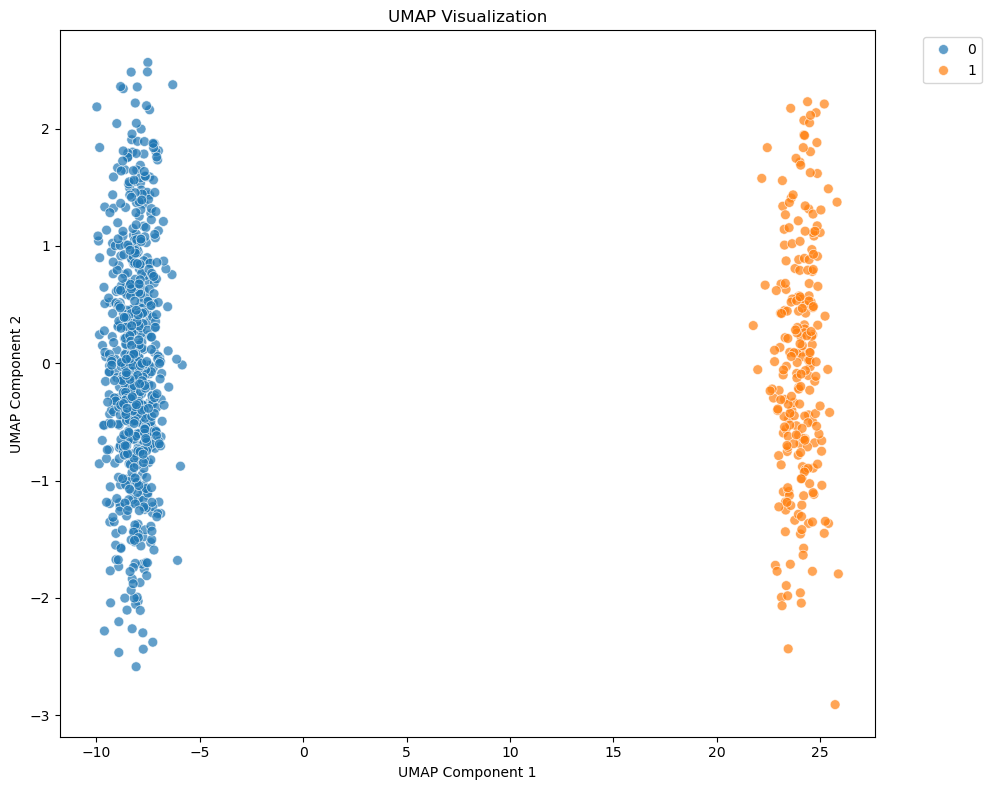

In [10]:


# Create DataFrame for plotting
umap_df = pd.DataFrame({
    'UMAP1': pca_emb[:, 0],
    'UMAP2': pca_emb[:, 2],
    'label': drug_y['BRD-K42805893-001-04-9::2.5::HTS'],
    'cell_line': [cell_meta_dict[c] for c in dataset['cell_line_name']]
})

# Plot with seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='label', 
                palette='tab10', alpha=0.7, s=50)
plt.title('UMAP Visualization')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
dataset['cell_line_name']

0          786O
1          786O
2          786O
3         A2780
4         A2780
         ...   
919     CORL105
920        T47D
921        T47D
922    PANC0504
923    PANC0504
Name: cell_line_name, Length: 924, dtype: object

In [14]:
from sklearn.decomposition import PCA

In [5]:
import lightgbm as lgbm
X_train, X_test, y_train, y_test = train_test_split(drug_X, drug_y['BRD-K64925568-001-01-8::2.5::HTS'], test_size=0.2, random_state=20)

In [11]:
np.corrcoef(drug_X.iloc[5:8,:])

array([[1.        , 0.91538865, 0.9137483 ],
       [0.91538865, 1.        , 0.91593312],
       [0.9137483 , 0.91593312, 1.        ]])

In [15]:
import lightgbm as lgbm
X_train, X_test, y_train, y_test = train_test_split(drug_X, drug_y['BRD-K42805893-001-04-9::2.5::HTS'], test_size=0.2, random_state=20)

In [ ]:
import lightgbm as lgbm
X_train, X_test, y_train, y_test = train_test_split(drug_X, drug_y['BRD-A00218260-001-03-4::2.5::HTS'], test_size=0.2, random_state=20)

In [ ]:

from sklearn.base import clone
kfold_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
wired_params = {'max_depth': 121, 'min_child_samples': 14, 'min_child_weight': 3.186667648998791, 'num_leaves': 283, 'subsample': 0.9536148394560624, 'scale_pos_weight': 8.844210722312107}
new_lgb  = Pipeline([
  ('classifier', LGBMClassifier(n_jobs = 8, is_unbalance = False, verbose = -1, n_estimators = 1000, subsample_freq=1, **wired_params))])
fit_params = {'classifier__eval_set':[(X_test, y_test)], 'classifier__eval_metric' :'average_precision', 'classifier__callbacks': [lgbm.early_stopping(stopping_rounds=100)]}

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

In [ ]:
def custom_cv():
    for fold_idx, (train_idx, test_idx) in enumerate(kfold_outer.split(X_train, y_train)):
        # Clone the estimator for this fold
        estimator_fold = clone(new_lgb)
        if hasattr(X_train, 'iloc'):  # pandas DataFrame
            X_train0, X_test = X_train.iloc[train_idx], X_train.iloc[test_idx]
        else:  # numpy array
            X_train0, X_test = X_train[train_idx], X_train[test_idx]
        if y_train is not None:
            if hasattr(y_train, 'iloc'):  # pandas Series
                y_train0, y_test = y_train.iloc[train_idx], y_train.iloc[test_idx]
            else:  # numpy array
                y_train0, y_test = y_train[train_idx], y_train[test_idx]
        estimator_fold.fit(X_train0, y_train0, **fit_params)

In [ ]:
sys.path.append('../')
from scripts.cross_validation_utils_ import outer_cross_validate

In [ ]:
outer_cross_validate(new_lgb, X_train, y_train, kfold_outer, scoring = 'average_precision', **fit_params)

In [ ]:
mlp =  MLPClassifier(hidden_layer_sizes=(100,))

In [100]:
sgd_search_params= {
        'l1_ratio':optuna.distributions.FloatDistribution(0.01, 0.2),
	'alpha':optuna.distributions.FloatDistribution(0.02, 0.05)
}
sgd =  SGDClassifier(n_jobs=8, 
                     random_state= 42,
                     loss= "log_loss",
                     penalty= "elasticnet",
                     class_weight = "balanced")

search_sgd_best = OptunaSearchCV(
            sgd,
            param_distributions=sgd_search_params,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='average_precision',
            n_jobs=2,
            n_trials=100,
            verbose=2
)

/scratch/ysu13/tmp/ipykernel_1313701/304715704.py:11: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  search_sgd_best = OptunaSearchCV(


In [6]:
from sklearn.decomposition import PCA
lgbm_search_params= {
        "max_depth": optuna.distributions.IntDistribution(3, 20),
        "min_child_samples": optuna.distributions.IntDistribution(3, 30),
        "min_child_weight": optuna.distributions.IntDistribution(3, 20),
        "learning_rate": optuna.distributions.FloatDistribution(0.01, 0.2),
        "num_leaves": optuna.distributions.IntDistribution(10, 200),
        "subsample": optuna.distributions.FloatDistribution(0.5, 1.0)
}
lgbm_search_params = {'classifier__' + key: lgbm_search_params[key] for key in lgbm_search_params}
lgb = Pipeline([
  ('classifier', LGBMClassifier(n_jobs=8, is_unbalance = False, verbose = -1, importance_type='gain', n_estimators = 500,  metric = None, subsample_freq= 1))
])
search_estimator_best_pipe = OptunaSearchCV(
            lgb,
            param_distributions=lgbm_search_params,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='average_precision',
            n_jobs=1,
            n_trials=100,
            verbose=2
)
def decay_rate(current_round):
  return 0.1 * (0.995 ** current_round) 

def sleep(env):
  if env.iteration % 200 == 0:
    sleep_duration = random.uniform(0.1, 0.2)
    time.sleep(sleep_duration)

def show_val(env):
    """
    A simple custom callback that prints the current iteration and validation score.
    """
    if env.evaluation_result_list:
        # Assuming the first metric on the first validation set
        metric_name = env.evaluation_result_list[0][0]
        metric_value = env.evaluation_result_list[0][2]
        if env.iteration % 300 == 0:
          sleep_duration = random.uniform(0.1, 0.2)
          time.sleep(sleep_duration)
          print(f"Iteration {env.iteration}: {metric_name} = {metric_value:.4f}")
  

/scratch/ysu13/tmp/ipykernel_1368336/2091107154.py:14: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  search_estimator_best_pipe = OptunaSearchCV(


In [9]:
CB_ = {}
def cb_wrapper(env):
    if str(env.model) in CB_:
        CB_[str(env.model)](env)
    else:
        CB_[str(env.model)] = lgbm.early_stopping(stopping_rounds=100, first_metric_only=True)
        CB_[str(env.model)](env)
    #ecb(env)

In [ ]:
classifier = search_estimator_best_pipe.best_estimator_['classifier']

In [7]:
pca = TruncatedSVD(X_train.shape[0])

scaler = StandardScaler()

import lightgbm as lgbm
#X_train, X_test, y_train, y_test = train_test_split(drug_X, drug_y['BRD-K42805893-001-04-9::2.5::HTS'], test_size=0.2, random_state=20)
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = X_train
X_train_pca= pca.fit_transform(X_train_scaled)
X_test_scaled = scaler.transform(X_test)
X_test_scaled = X_test
X_test_pca = pca.transform(X_test_scaled)

In [124]:
search_sgd_best.fit(X_train_pca, y_train)

[I 2025-07-23 01:16:19,705] A new study created in memory with name: no-name-fe8e0ba9-0cc0-4e4b-8fc0-02e804a1615c
[I 2025-07-23 01:16:19,989] Trial 1 finished with value: 0.8067973411986251 and parameters: {'l1_ratio': 0.11042451808060956, 'alpha': 0.02630041374766423}. Best is trial 1 with value: 0.8067973411986251.
[I 2025-07-23 01:16:20,049] Trial 0 finished with value: 0.8048089238495427 and parameters: {'l1_ratio': 0.18923058390039807, 'alpha': 0.030600213492123704}. Best is trial 1 with value: 0.8067973411986251.
[I 2025-07-23 01:16:20,249] Trial 2 finished with value: 0.8003933765539474 and parameters: {'l1_ratio': 0.09796697172517264, 'alpha': 0.023929735205427096}. Best is trial 1 with value: 0.8067973411986251.
[I 2025-07-23 01:16:20,370] Trial 3 finished with value: 0.8137190044462101 and parameters: {'l1_ratio': 0.11224698525635313, 'alpha': 0.03455116476570925}. Best is trial 3 with value: 0.8137190044462101.
[I 2025-07-23 01:16:20,455] Trial 4 finished with value: 0.82630

OptunaSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
               estimator=SGDClassifier(class_weight='balanced', loss='log_loss',
                                       n_jobs=8, penalty='elasticnet',
                                       random_state=42),
               n_jobs=2, n_trials=100,
               param_distributions={'alpha': FloatDistribution(high=0.05, log=False, low=0.02, step=None),
                                    'l1_ratio': FloatDistribution(high=0.2, log=False, low=0.01, step=None)},
               scoring='average_precision', verbose=2)

In [128]:
X_train_scaled.std(0)

array([1., 1., 1., ..., 1., 1., 1.], shape=(17651,))

In [125]:

importance = search_sgd_best.best_estimator_.coef_[0]
pc_var = np.sqrt(pca.explained_variance_)
comps = pca.components_

In [130]:
new_importances = ((importance*pc_var)[:, np.newaxis] * np.abs(comps/X_train_scaled.std(0))).sum(axis=0)
new_importances2 = ((stable_softmax(importance)* pc_var)[:, np.newaxis] * np.abs(comps/X_train_scaled.std(0))).sum(axis=0)
new_importances3 = (importance[:, np.newaxis] * np.abs(comps/X_train_scaled.std(0))).sum(axis=0)
new_importances4 = (stable_softmax(importance)[:, np.newaxis] * np.abs(comps/X_train_scaled.std(0))).sum(axis=0)


In [132]:
pd.DataFrame({'features':X_train.keys(), 
              'importances':abs(new_importances), 
              'importances2':abs(new_importances2),
              'importances3':abs(new_importances3),
              'importances4':abs(new_importances4)
              })

,features,importances,importances2,importances3,importances4
0,SHOC2,0.203883,0.025063,0.018879,0.005669
1,NDUFA12,0.130369,0.026063,0.017384,0.006323
2,SDAD1,0.168709,0.018486,0.017740,0.004242
3,FAM98A,0.059108,0.023826,0.006923,0.005701
4,ZNF253,0.170291,0.017682,0.030053,0.003841
...,...,...,...,...,...
17646,SPDYE16,0.039773,0.018890,0.001559,0.004298
17647,USP17L11,0.036258,0.018742,0.012380,0.003850
17648,GAGE1,0.179661,0.019333,0.028986,0.003903
17649,SMN1,0.013683,0.020348,0.004682,0.004681


In [10]:
search_estimator_best_pipe.fit(X_train_pca, y_train, **{'classifier__eval_set':[(X_test_pca, y_test)], 
                             'classifier__eval_metric' :'average_precision', 
                             'classifier__callbacks': [cb_wrapper, lgbm.reset_parameter(learning_rate=decay_rate)]})
importance = search_estimator_best_pipe.best_estimator_['classifier'].feature_importances_
pc_var = np.sqrt(pca.explained_variance_)
comps = pca.components_


[I 2025-07-23 01:27:07,894] A new study created in memory with name: no-name-2bd550a2-79d9-439d-8072-f58811afd3ac


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[94]	valid_0's average_precision: 0.882938
Evaluated only: average_precision


/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[120]	valid_0's average_precision: 0.848469
Evaluated only: average_precision


/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

Early stopping, best iteration is:
[96]	valid_0's average_precision: 0.903797
Evaluated only: average_precision
Training until validation scores don't improve for 100 rounds


/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Early stopping, best iteration is:
[299]	valid_0's average_precision: 0.910941
Evaluated only: average_precision
Training until validation scores don't improve for 100 rounds


/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/users/ysu13/miniforge3/envs/drug_sensitivity_ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-07-23 01:29:46,274] Trial 99 finished with value: 0.8927505074142499 and parameters: {'classifier__max_depth': 13, 'classifier__min_child_samples': 17, 'classifier__min_child_weight': 3, 'classifier__learning_rate': 0.17885619663601884, 'classifier__num_leaves': 195, 'classifier__subsample': 0.5787672449746439}. Best is trial 42 with value: 0.8964928858926473.


Early stopping, best iteration is:
[118]	valid_0's average_precision: 0.962052
Evaluated only: average_precision
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[106]	valid_0's average_precision: 0.952859
Evaluated only: average_precision


In [17]:
X_train_scaled.std().values

array([0.28338942, 0.14142411, 0.30016278, ..., 0.32457964, 0.56604029,
       0.19362321], shape=(17651,))

In [13]:
new_importances = (np.abs((importance*pc_var)[:, np.newaxis]) * np.abs(comps/X_train_scaled.std(0).values)).sum(axis=0)
new_importances2 = ((stable_softmax(importance)* pc_var)[:, np.newaxis] * np.abs(comps/X_train_scaled.std(0).values)).sum(axis=0)
new_importances3 = np.abs((importance[:,np.newaxis]*comps).sum()*X_train_scaled.std(0).values)
new_importances4 = (stable_softmax(importance)[:, np.newaxis] * np.abs(comps/X_train_scaled.std(0).values)).sum(axis=0)


In [107]:
importance[0]

array([ 7.70291889e-02,  1.77137047e-01, -1.70216097e-01,  1.13781705e-01,
       -3.23717455e-01,  2.63954258e-01, -4.98184047e-01,  1.33687677e-01,
        1.19548574e-01, -3.71004024e-01,  4.23029693e-02,  3.81585826e-01,
       -2.82517136e-01,  8.77997136e-02, -5.82383407e-01,  3.36361533e-01,
       -4.39903738e-01,  1.20629993e-01,  0.00000000e+00,  2.08232388e-01,
        1.55261061e-01, -2.28041629e-01, -2.41271772e-01,  1.14168365e-01,
        4.66078157e-02,  2.15263531e-01,  1.89832115e-01, -8.31147246e-02,
       -2.21472064e-01,  1.09540689e-01, -2.38969747e-01, -5.25822148e-02,
        2.87909619e-01,  5.18969742e-01, -5.56016107e-01,  1.82287607e-01,
        0.00000000e+00,  6.13831836e-01,  3.33486437e-01,  4.78680851e-01,
        2.95042584e-01, -1.15336042e-01, -1.51920606e-01,  0.00000000e+00,
       -3.43269094e-01,  0.00000000e+00, -2.27212317e-01, -3.97943488e-01,
        0.00000000e+00, -5.33220854e-02, -4.61746894e-01,  7.08320457e-02,
       -3.69100848e-01, -

In [1]:
5945*453

2693085

In [12]:
def stable_softmax(x):
    # Subtract the maximum value for numerical stability
    shifted_x = x - np.max(x)
    exp_shifted_x = np.exp(shifted_x)
    return exp_shifted_x / np.sum(exp_shifted_x)

In [ ]:
new_importances = (stable_softmax(importance)[:,np.newaxis] *np.abs(pca.components_)).sum(axis = 0)

In [ ]:
np.where(search_estimator_best_pipe.best_estimator_['classifier'].feature_importances_ == search_estimator_best_pipe.best_estimator_['classifier'].feature_importances_)


In [14]:
pd.DataFrame({'features':X_train_scaled.keys(), 
              'importances':abs(new_importances), 
              'importances2':abs(new_importances2),
              'importances3':abs(new_importances3),
              'importances4':abs(new_importances4)
              })

,features,importances,importances2,importances3,importances4
0,SHOC2,165.215896,0.105518,1016.316464,0.020655
1,NDUFA12,224.231822,0.244210,507.187804,0.047803
2,SDAD1,160.039500,0.134200,1076.470620,0.026269
3,FAM98A,210.009598,0.097239,650.120000,0.019034
4,ZNF253,153.523568,0.137517,896.198147,0.026918
...,...,...,...,...,...
17646,SPDYE16,162.947932,0.137164,2331.033702,0.026849
17647,USP17L11,410.103697,0.426696,1352.601397,0.083523
17648,GAGE1,410.771763,0.442967,1164.036547,0.086708
17649,SMN1,125.116366,0.083945,2029.984314,0.016432


In [ ]:
def test_lgbm():
   return search_estimator_best.fit(X_train, y_train, 
                          **{'classifier__eval_set':[(X_test, y_test)], 
                             'classifier__eval_metric' :'average_precision', 
                             'classifier__callbacks': [cb_wrapper, 
                                                       lgbm.reset_parameter(learning_rate=decay_rate)]})


In [ ]:
searcher = test_lgbm()

In [ ]:
pd.DataFrame(searcher.cv_results_)

In [ ]:
best= searcher.best_estimator_

In [ ]:
a

In [ ]:
a.evals_result_['valid_0']['average_precision'][130:150]

In [ ]:
search_estimator_best.

In [ ]:
xgb_search_params = {
 	    "max_depth" : optuna.distributions.IntDistribution(5, 200),
 	    "n_estimators" : optuna.distributions.IntDistribution(50, 200),
        "min_child_weight": optuna.distributions.IntDistribution(3, 20),
        "learning_rate": optuna.distributions.FloatDistribution(0.01, 0.2),
        "subsample": optuna.distributions.FloatDistribution(0.5, 1.0)
    }
xgb_search_params= {'classifier__' + key: xgb_search_params[key] for key in xgb_search_params}
xgb = Pipeline([('classifier', XGBClassifier( n_jobs = 16))])
xgb_estimator_best = OptunaSearchCV(
            xgb,
            param_distributions=xgb_search_params,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='f1',
            n_jobs=2,
            n_trials=20,
            verbose=2
)

In [ ]:
xgb_estimator_best.fit(X_train, y_train)
best= xgb_estimator_best.best_estimator_

In [ ]:
xgb_cpu = Pipeline([('classifier', XGBClassifier( n_jobs = 16, min_child_weight = 10))])
xgb_cpu.fit(X_train, y_train)

In [ ]:
adb = Pipeline([('classifier', AdaBoostClassifier())])
adb.fit(X_train, y_train)

In [ ]:
xgb_gpu = Pipeline([('classifier', XGBClassifier(  max_depth = 5, device='cuda', tree_method = 'hist'))])
xgb_gpu.fit(X_train, y_train)

In [ ]:
clf.fit(X_train , y_train)

In [ ]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [ ]:
cu_rf = Pipeline([('classifier', cuRF())])

In [ ]:

skl_rf = Pipeline([('classifier', RandomForestClassifier(n_jobs = 10))])


In [ ]:
sgd = Pipeline([('scaler', StandardScaler(with_mean=False)),
		 ('classifier',SGDClassifier(penalty = 'elasticnet', loss = 'log_loss', n_jobs = 20, class_weight='balanced'))])
search_params = {
   'l1_ratio': optuna.distributions.FloatDistribution(0.0, 0.2),
    'alpha': optuna.distributions.FloatDistribution(5e-3, 5e-2, log=True),
    'max_iter': optuna.distributions.IntDistribution(1000, 2500)
}
optuna_search_params = {
 	    "max_depth" : optuna.distributions.IntDistribution(5, 20),
 	    "n_estimators" : optuna.distributions.IntDistribution(50, 200),
    }
search_params= {'classifier__' + key: search_params[key] for key in search_params}
optuna_search_params = {'classifier__' + key: optuna_search_params[key] for key in optuna_search_params}
search_estimator_best = OptunaSearchCV(
            xgb_cpu,
            param_distributions=optuna_search_params,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='f1',
            n_jobs=4,
            n_trials=20,
            verbose=2
)

In [ ]:
search_estimator_best.fit(X_train, y_train)
best= search_estimator_best.best_estimator_


In [ ]:
search_estimator_best.fit(X_train, y_train)
best= search_estimator_best.best_estimator_


In [ ]:
y_pred = mlp.predict_proba(X_test.values)[:,1]
y_pred0 = best.predict(X_test)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)
aupr_score = average_precision_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

In [ ]:
best.predict_proba(X_test.values)

In [ ]:
sgd2 = SGDClassifier(penalty = 'elasticnet', random_state=777, loss = 'log_loss', n_jobs = 20, alpha = 0.01, l1_ratio = 0.2, max_iter=5000,class_weight='balanced')
sgd2.fit(X_train, y_train)

In [ ]:
plt.hist(best['classifier'].coef_[0], bins =100)
plt.show()

In [ ]:
pd.DataFrame({'feature': list(X_train.columns),
					'importances': clf['classification'].feature_importances_ * 100}).\
					 sort_values('importances', ascending = False)

In [ ]:
pd.DataFrame({'feature': list(X_train.columns),
					'importances': xgb2['classifier'].feature_importances_ * 100}).\
					 sort_values('importances', ascending = False)

In [ ]:
y_pred = sgd2.predict_proba(X_train)[:,1]
precision, recall, thresholds = precision_recall_curve(y_train, y_pred)
aupr_score = average_precision_score(y_train, y_pred)
fpr, tpr, _ = roc_curve(y_train, y_pred)
roc_auc = auc(fpr, tpr)

In [ ]:
from sklearn_evaluation.plot import confusion_matrix, ConfusionMatrix

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

In [ ]:
a.ax_=

In [ ]:
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'AUPR curve (area = {aupr_score:.5f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="lower left")
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.show()

In [ ]:
%timeit cross_validate(xgb, X_train, y_train['BRD-A00077618-236-07-6::2.5::HTS'], scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], cv=kfold,  n_jobs=1)

In [ ]:


%timeit cross_validate(xgb1, X_train, y_train['BRD-A00077618-236-07-6::2.5::HTS'], scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], cv=kfold,  n_jobs=20)


In [ ]:
xgb2 = XGBClassifier(learning_rate= 0.07297156269889893, max_depth=6, min_child_weight= 1, subsample=0.8042517018984596, n_jobs = 4 )
%timeit cross_validate(xgb2, X_train, y_train['BRD-A00077618-236-07-6::2.5::HTS'], scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], cv=kfold,  n_jobs=5)


In [ ]:
xgb3 = XGBClassifier(learning_rate= 0.07297156269889893, max_depth=6, min_child_weight= 1, subsample=0.8042517018984596, n_jobs = 15 )
%timeit cross_validate(xgb3, X_train, y_train['BRD-A00077618-236-07-6::2.5::HTS'], scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], cv=kfold,  n_jobs=5)


In [ ]:
from sklearn.metrics import get_scorer
for s in ['balanced_accuracy', 'precision', 'recall', 'f1', 'average_precision', 'roc_auc']:
    score_ = get_scorer(s)
    print(score_(xgb3, X_test, y_test))

In [ ]:
xgb3.fit(X_train, y_train)

In [ ]:
score_(xgb3, X_test, y_test)

In [ ]:
# SOME PARAMETERS FOR GRIDSEARCH
GRID_SEARCH_PARAM = {
'XGB':{
 	"learning_rate" : [0.05,0.10,0.15,0.20],
 	"max_depth" : [ 3, 4, 5, 6, 8, 10, 12, 15],
 	"min_child_weight" : [ 1, 3, 5, 7 ],
 	"gamma": [ 0.0, 0.1, 0.2 , 0.3, 0.4 ],
	 "n_estimators": [50, 100, 200]
},
 'RF':{
	 "n_estimators": [100, 150, 250],
	 "max_depth" : [20, 50, 100, 200],
 },
 'SGD':{
	 'l1_ratio':[0.2, 0.15, 0.1, 0.05],
	 'alpha':[0.02, 0.05]
 }
}

# Basic function to handel sklearn and traditional model training and basic hyperparameter optimization
# TODO refactor this into a class maybe, class DrugModel
def skl_drug_model(X, Y, drug, model = XGBClassifier, oversample = True, fixed_params={}, search_params = {}, search_method = 'gridcv'):

	assert model in [XGBClassifier, RandomForestClassifier, SGDClassifier, LGBMClassifier], f' {model} type not supported'

	
	y = Y[drug]

	 # split X and y into training and testing sets
	X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)


	if oversample:
		ros = SMOTE(random_state=72)
		X_res, y_res = ros.fit_resample(X_train, y_train)
		oversample = 'oversample'
	else:
		X_res, y_res = X_train, y_train
		oversample = ''


	 # instantiate the classifier
	 

	# k-fold cross validation using multiple metric evaluation
	kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
	 #cv_results = cross_validate(xgbc, X_train, y_train, cv=kfold, scoring= ['accuracy', 'precision', 'recall', 'f1'], n_jobs = 10)
	if oversample:
		imba_pipeline = Pipeline([('sampling', SMOTE(random_state=72)), 
							  ('classifier', model(n_jobs=10, **fixed_params))])
		grid_search_parameters = {'classifier__' + key: search_params[key] for key in search_params}
	else:
		imba_pipeline = model(**fixed_params, n_jobs=20)
		grid_search_parameters = search_params
	 #cross_val_score(imba_pipeline, X_train, y_train, scoring='recall', cv=kf)
	model0 = model(**fixed_params, n_jobs=20)

	 #perform gridsearch if needed
	if search_method == 'gridcv' and search_params:
		grid_imba = HalvingRandomSearchCV(imba_pipeline, param_distributions=grid_search_parameters, cv=kfold, scoring='precision')
		#grid_imba.fit(X_train, y_train) 
		cv_results = cross_validate(grid_imba, X, y, scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], cv=kfold,  n_jobs=10)
		print(cv_results)
		print(grid_imba)
		#return cv_results, grid_imba
		#best_params = {key.removeprefix('classifier__'):grid_imba.best_params_[key] for key in grid_imba.best_params_}
		#print(best_params)
		#model0.set_params(**best_params)
	else:
		cv_results = cross_validate(model0, X_train, y_train, scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], cv=kfold, njobs = 10)
		grid_imba = model0
	 
	if oversample:
		imba_pipeline = Pipeline([('sampling', SMOTE(random_state=72)), 
							  ('classifier', model0)])
	else:
		imba_pipeline = model0
		  
	# generate cross validation results of best model with correct oversampling 
	# OVERSAMPLING must come after validation split for correct validation , thus the use of pipeline
	# cross_validate function will first split into train/validate, then feed training data into pipeline (oversampling + training)
	#cv_results = cross_validate(imba_pipeline, X_train, y_train, cv=kfold, scoring= ['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], n_jobs = 20)
	cv_results = pd.DataFrame(cv_results)
	print(cv_results)

	 # declare parameters
	 

	 # fit the classifier to the training data
	model0.fit(X_res, y_res)

	 # save the trained model
	
		  
	final_results = {
		'best_model': model0,
		'drug': drug,
		'model_class': model,
		'model_search': grid_imba,
		'search_method': search_method,
		'X_test': X_test,
		'Y_test': y_test,
		'X_train': X_train,
		'Y_train': y_train,
		'cv_results':cv_results,
		'oversample': True if oversample else False
	}

	return final_results


def write_drug_model_result(model_results, out_dir):
	 
	model0 = model_results['best_model']
	oversample = 'oversample' if model_results['oversample'] else ''
	drug = model_results['drug']
	model_class = model_results['model_class']

	model_name = {
		  XGBClassifier:'XGBClassifier',
		  RandomForestClassifier:'RandomForestClassifier',
		  SGDClassifier:'SGDClassifier',
		  LGBMClassifier:'LGBMClassifier'

	}[model_class]

	full_out_dir = f'{out_dir}/{oversample}/{drug}/'
	X_test, y_test = model_results['X_test'], model_results['Y_test']
	X_train, y_train = model_results['X_train'], model_results['Y_train']
	y_pred = model0.predict(X_test)

	os.makedirs(full_out_dir, exist_ok=True)

	joblib.dump(model0, f'{full_out_dir}/{model_name}_{drug}.joblib')
	
	model_results['cv_results'].to_csv(f'{full_out_dir}/{model_name}_cv_results_{drug}.csv')

	print(drug,
		 f'{model_class}_model_parameters', model0, "\n",
		 "confusion_matrix:", "\n", confusion_matrix(y_test, y_pred), "\n",
		 file=open(f'{full_out_dir}/{model_name}_confusion_matrix.txt', "a"))

	model_report = classification_report(y_test, y_pred, output_dict=True, labels=np.unique(y_pred))
	model_report = pd.DataFrame(model_report).transpose()
	
	if (model_report.index == "1").any() == True:
		r1 = pd.DataFrame(model_report.loc["1"]).transpose()
		r1.to_csv(f'{full_out_dir}/{model_name}_classification_report_{drug}.csv')
	else:
		print(drug, "Nothing predicted as 1",
			   file=open(f'{out_dir}/{oversample}/{model_name}_classification_report_log.txt', "a"))

	 

	 # feature importance with XGBoost
	if model_class in [XGBClassifier, RandomForestClassifier]:
		fi = pd.DataFrame({'feature': list(X_train.columns),
					'importances': model0.feature_importances_ * 100}).\
					 sort_values('importances', ascending = False)
		fi.to_csv(f'{full_out_dir}/{model_name}_feature_importance_{drug}.csv')

		# plot feature importance
		plt.figure(figsize=(10, 8))
		sns.barplot(x='importances', y='feature', data=fi.head(20))
		plt.title(f'{model_name} Feature Importance for {drug}')
		plt.tight_layout()
		plt.savefig(f'{full_out_dir}/{model_name}_feature_importance_{drug}.png')
		plt.close()
	# save the model report
	model_report.to_csv(f'{full_out_dir}/{model_name}_classification_report_{drug}.csv')
	print(f"Model for {drug} saved to {full_out_dir}/{model_name}_{drug}.joblib")
	return model_results




In [ ]:
model_map = {}
for d in drug_list[0:1]:
	cv_res1, grid_imba1 = skl_drug_model(drug_X, drug_y, d, 
		model = XGBClassifier, 
		oversample = False, 
		fixed_params={},
		search_params=GRID_SEARCH_PARAM['XGB']
	)


In [ ]:
model_map = {}
for d in drug_list[0:1]:
	model_map[d] = skl_drug_model(drug_X, drug_y, d, 
		model = LGBMClassifier, 
		oversample = False,
		search_params={},
		fixed_params={}
		)

In [ ]:
write_drug_model_result(model_map['BRD-A00077618-236-07-6::2.5::HTS'], out_dir = 'output')

In [ ]:
starttime = time.time()
grid_search = skl_drug_model('BRD-A00100033-001-08-9::2.5::HTS',   oversample = True, model = RandomForestClassifier
)
endtime = time.time()